# BTC/USDT Spot Cross-Exchange Comparison

Fetch the same BTC/USDT spot market from Binance, Bybit, and Bitget through the public `Exchange` API, align common timestamps, and compare close-price spreads.

In [1]:
from __future__ import annotations

from datetime import UTC, datetime

import matplotlib.pyplot as plt

from quantleet.integrations.venues.ccxt import Exchange, MarketType

fatal: bad revision 'HEAD'


In [2]:
EXCHANGES = ["binance", "bybit", "bitget"]
TIMEFRAME = "1h"
LIMIT = 200
SYMBOL = "BTC/USDT"

rows_by_exchange: dict[str, list] = {}
for name in EXCHANGES:
    exchange = Exchange(name=name, market_type=MarketType.SPOT)
    rows_by_exchange[name] = exchange.fetch_ohlcv(
        symbol=SYMBOL,
        timeframe=TIMEFRAME,
        limit=LIMIT,
    )
rows_by_exchange.keys()

dict_keys(['binance', 'bybit', 'bitget'])

In [3]:
def is_strictly_ascending(rows: list) -> bool:
    pairs = zip(rows, rows[1:], strict=False)
    return all(left.timestamp < right.timestamp for left, right in pairs)


for name, rows in rows_by_exchange.items():
    assert rows, f"{name} fetch returned no rows"
    assert is_strictly_ascending(rows), f"{name} timestamps are not strictly ascending"
    summary = {
        "rows": len(rows),
        "start": datetime.fromtimestamp(rows[0].timestamp / 1000, UTC).isoformat(),
        "end": datetime.fromtimestamp(rows[-1].timestamp / 1000, UTC).isoformat(),
    }
    print(name, summary)

binance {'rows': 200, 'start': '2026-03-07T02:00:00+00:00', 'end': '2026-03-15T09:00:00+00:00'}
bybit {'rows': 200, 'start': '2026-03-07T02:00:00+00:00', 'end': '2026-03-15T09:00:00+00:00'}
bitget {'rows': 200, 'start': '2026-03-07T02:00:00+00:00', 'end': '2026-03-15T09:00:00+00:00'}


In [4]:
timestamp_sets = [{row.timestamp for row in rows} for rows in rows_by_exchange.values()]
shared_timestamps = sorted(set.intersection(*timestamp_sets))
assert shared_timestamps, "no common timestamps across exchanges"
print("shared_timestamps", len(shared_timestamps))

aligned_close: dict[str, dict[int, float]] = {}
for name, rows in rows_by_exchange.items():
    aligned_close[name] = {
        row.timestamp: row.close for row in rows if row.timestamp in shared_timestamps
    }
    assert len(aligned_close[name]) == len(shared_timestamps)

shared_timestamps 200


In [5]:
reference = "binance"
spread_summary: list[dict[str, float | str]] = []

for name in EXCHANGES:
    if name == reference:
        continue
    spreads = [aligned_close[name][ts] - aligned_close[reference][ts] for ts in shared_timestamps]
    abs_spreads = [abs(value) for value in spreads]
    spread_summary.append(
        {
            "exchange": name,
            "latest_spread": spreads[-1],
            "mean_abs_spread": sum(abs_spreads) / len(abs_spreads),
            "max_abs_spread": max(abs_spreads),
        }
    )

spread_summary

[{'exchange': 'bybit',
  'latest_spread': -3.970000000001164,
  'mean_abs_spread': 4.874899999999252,
  'max_abs_spread': 25.669999999998254},
 {'exchange': 'bitget',
  'latest_spread': 0.569999999992433,
  'mean_abs_spread': 8.279800000000687,
  'max_abs_spread': 34.08999999999651}]

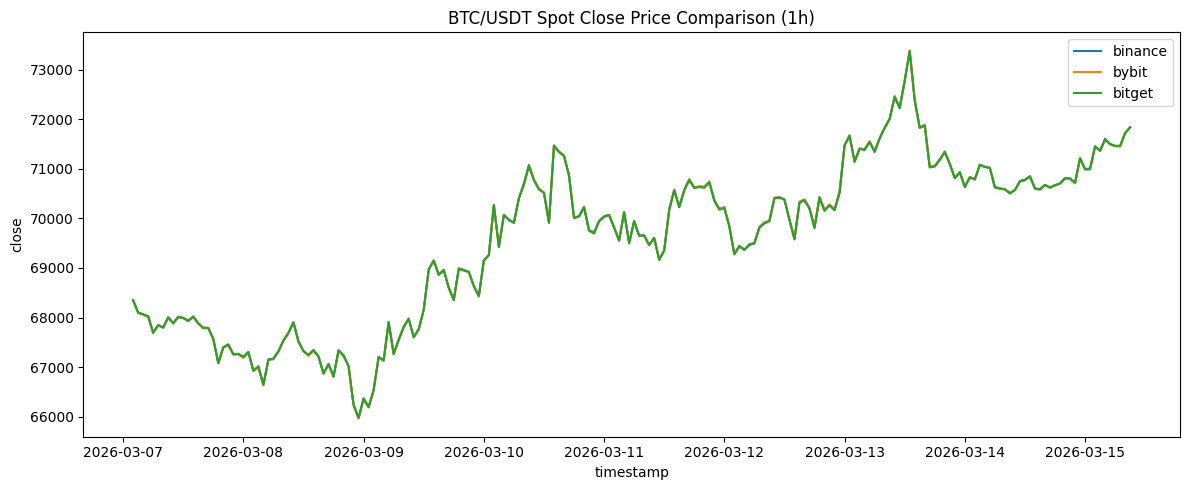

In [6]:
plt.figure(figsize=(12, 5))
xs = [datetime.fromtimestamp(ts / 1000, UTC) for ts in shared_timestamps]
for name in EXCHANGES:
    ys = [aligned_close[name][ts] for ts in shared_timestamps]
    plt.plot(xs, ys, label=name)
plt.title("BTC/USDT Spot Close Price Comparison (1h)")
plt.xlabel("timestamp")
plt.ylabel("close")
plt.legend()
plt.tight_layout()
plt.show()